In [1]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.metrics import AUC, Precision, Recall
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LeakyReLU, ELU
from sklearn.metrics import  accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Mount your personal Google drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# Load the dataset
dfs = []
direc = "drive/MyDrive/StructuralBioinformatics/data/features_ring"
i = 0
for filename in os.listdir(direc):
    dfs.append(pd.read_csv(direc + '/' + filename, sep='\t'))

df = pd.concat(dfs)
#df = df.iloc[:,:-1] # remove last column (only if needed!)
display(df)
print(f"Original df shape: {df.shape}")

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_phi,t_psi,t_a1,t_a2,t_a3,t_a4,t_a5,t_3di_state,t_3di_letter,Interaction
0,6qsp,A,276,,A,G,0.632,-1.120,-0.338,-0.591,...,-2.322,2.373,1.831,-0.561,0.533,-0.277,1.648,6.0,G,VDW
1,6qsp,A,209,,E,-,0.134,-2.310,1.325,1.357,...,-1.788,2.740,-1.343,0.465,-0.862,-1.020,-0.255,4.0,E,HBOND
2,6qsp,A,4,,I,E,0.030,-1.845,2.017,-1.239,...,-2.390,2.897,0.931,-0.179,-3.005,-0.503,-1.853,2.0,C,NaN
3,6qsp,A,110,,D,H,0.018,-1.093,-0.902,1.050,...,-1.088,-0.766,-0.228,1.399,-4.760,0.670,-2.647,17.0,R,HBOND
4,6qsp,A,273,,I,-,0.160,-2.218,2.827,-1.239,...,-1.551,-0.116,1.357,-1.453,1.477,0.113,-0.837,13.0,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,3aia,B,6,,F,E,0.010,-1.998,2.111,-1.006,...,-2.087,2.129,-1.239,-0.547,2.131,0.393,0.816,4.0,E,VDW
750,3aia,A,138,,M,E,0.340,-0.820,-0.590,-0.663,...,-1.693,2.458,-0.228,1.399,-4.760,0.670,-2.647,14.0,O,HBOND
751,3aia,B,72,,E,T,0.423,-1.981,-0.224,1.357,...,-0.971,2.214,0.189,2.081,-1.628,0.421,-1.392,16.0,Q,NaN
752,3aia,B,134,,Y,E,0.054,-2.202,2.358,0.260,...,-1.349,2.036,1.050,0.302,-3.656,-0.259,-3.242,2.0,C,NaN


Original df shape: (2968986, 32)


In [4]:
# Group by rows with same residues and different interactions (for multilabel)
df = df.astype({col: str for col in df.select_dtypes(include=['object']).columns})
df = df.groupby(df.columns.values[:-1].tolist()).agg(lambda x: ' '.join(x)).reset_index()
display(df)

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_phi,t_psi,t_a1,t_a2,t_a3,t_a4,t_a5,t_3di_state,t_3di_letter,Interaction
0,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-1.935,2.090,0.931,-0.179,-3.005,-0.503,-1.853,6.0,G,nan
1,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-1.118,2.453,0.189,2.081,-1.628,0.421,-1.392,2.0,C,HBOND VDW
2,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-2.500,2.812,-1.006,-0.590,1.891,-0.397,0.412,19.0,T,nan
3,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-2.032,2.307,1.357,-1.453,1.477,0.113,-0.837,2.0,C,HBOND
4,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-2.139,2.423,-1.006,-0.590,1.891,-0.397,0.412,0.0,A,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475208,9o8y,C,239,,L,E,0.171,-2.153,2.416,-1.019,...,-2.046,2.384,-1.019,-0.987,-1.505,1.266,-0.912,2.0,C,HBOND VDW
2475209,9o8y,C,240,,P,E,0.434,-1.399,2.599,0.189,...,-2.299,2.805,-0.228,1.399,-4.760,0.670,-2.647,16.0,Q,nan
2475210,9o8y,C,241,,S,-,0.200,-1.194,2.781,-0.228,...,1.328,0.105,-0.384,1.652,1.330,1.045,2.064,14.0,O,HBOND VDW
2475211,9o8y,C,241,,S,-,0.200,-1.194,2.781,-0.228,...,-1.376,-0.363,-0.228,1.399,-4.760,0.670,-2.647,12.0,M,VDW


In [5]:
# Drop rows with NaN interactions
df['Interaction'] = df['Interaction'].replace('nan', np.nan)
df = df.dropna(subset=['Interaction'])
df.shape
display(df)

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_phi,t_psi,t_a1,t_a2,t_a3,t_a4,t_a5,t_3di_state,t_3di_letter,Interaction
1,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-1.118,2.453,0.189,2.081,-1.628,0.421,-1.392,2.0,C,HBOND VDW
3,1aba,A,2,,F,E,0.010,-1.282,2.634,-1.006,...,-2.032,2.307,1.357,-1.453,1.477,0.113,-0.837,2.0,C,HBOND
6,1aba,A,3,,K,E,0.307,-2.068,2.220,1.831,...,-2.139,2.423,-1.006,-0.590,1.891,-0.397,0.412,0.0,A,HBOND VDW
7,1aba,A,4,,V,E,0.000,-2.103,1.986,-1.337,...,-2.032,2.307,1.357,-1.453,1.477,0.113,-0.837,2.0,C,HBOND
8,1aba,A,4,,V,E,0.000,-2.103,1.986,-1.337,...,-1.836,2.317,-1.006,-0.590,1.891,-0.397,0.412,19.0,T,VDW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475207,9o8y,C,239,,L,E,0.171,-2.153,2.416,-1.019,...,-2.299,2.805,-0.228,1.399,-4.760,0.670,-2.647,16.0,Q,VDW
2475208,9o8y,C,239,,L,E,0.171,-2.153,2.416,-1.019,...,-2.046,2.384,-1.019,-0.987,-1.505,1.266,-0.912,2.0,C,HBOND VDW
2475210,9o8y,C,241,,S,-,0.200,-1.194,2.781,-0.228,...,1.328,0.105,-0.384,1.652,1.330,1.045,2.064,14.0,O,HBOND VDW
2475211,9o8y,C,241,,S,-,0.200,-1.194,2.781,-0.228,...,-1.376,-0.363,-0.228,1.399,-4.760,0.670,-2.647,12.0,M,VDW


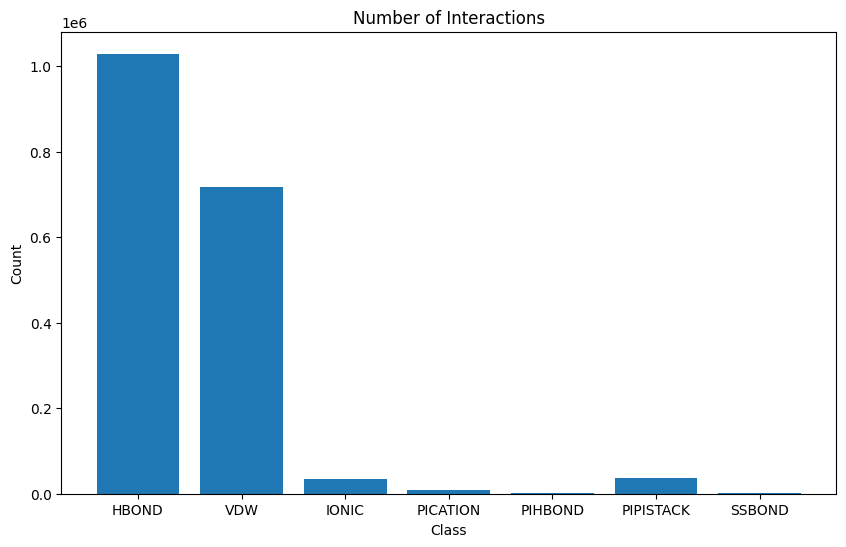

In [5]:
# Count the total number of interactions
labels = ['HBOND', 'VDW', 'IONIC', 'PICATION', 'PIHBOND', 'PIPISTACK', 'SSBOND']

counts = [0, 0, 0, 0, 0, 0, 0]
for i, label in enumerate(labels):
    counts[i] = df['Interaction'].str.contains(label, na=False).sum()

plt.figure(figsize=(10,6))
plt.bar(labels, counts)
plt.title('Number of Interactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [6]:
# Preprocess
df.replace(' ', np.nan, inplace=True)

# Deal with nan values
imputer = SimpleImputer(strategy='mean')
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

excluded_columns = ['pdb_id', 'Interaction']
categorical_columns = [col for col in df.columns if col not in excluded_columns and col not in numeric_columns]
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = imputer_cat.fit_transform(df[categorical_columns])

# Extract target
target = df["Interaction"]

# Label encoding for categorical columns
label_encoder = LabelEncoder()

for col in categorical_columns:
  df[col] = label_encoder.fit_transform(df[col])

# Normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[numeric_columns])
df[numeric_columns] = features_scaled

features_scaled = scaler.fit_transform(df[categorical_columns])
df[categorical_columns] = features_scaled

# Extract features
features = df.drop(columns=["pdb_id", "Interaction"])

# Convert the multi-label target into binary (one-hot encoding)
labels = ['HBOND', 'VDW', 'IONIC', 'PICATION', 'PIHBOND', 'PIPISTACK', 'SSBOND']
mlb = MultiLabelBinarizer(classes=labels)
target_encoded = mlb.fit_transform(target.str.split())  # Assuming interaction can be a list of labels

In [7]:
def plot_correlation_heatmap(df: pd.core.frame.DataFrame, title_name: str = 'Correlation') -> None:
    # create excluded list
    excluded_columns = ['pdb_id', 'Interaction']

    # Create a list of columns excluding the excluded_columns.
    columns_without_excluded = [col for col in df.columns if col not in excluded_columns]

    corr = df[columns_without_excluded].corr()
    fig, axes = plt.subplots(figsize=(14, 10))
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, linewidths=.5, cmap='YlOrBr_r', annot=True, annot_kws={"size": 6})
    plt.title(title_name)
    plt.show()

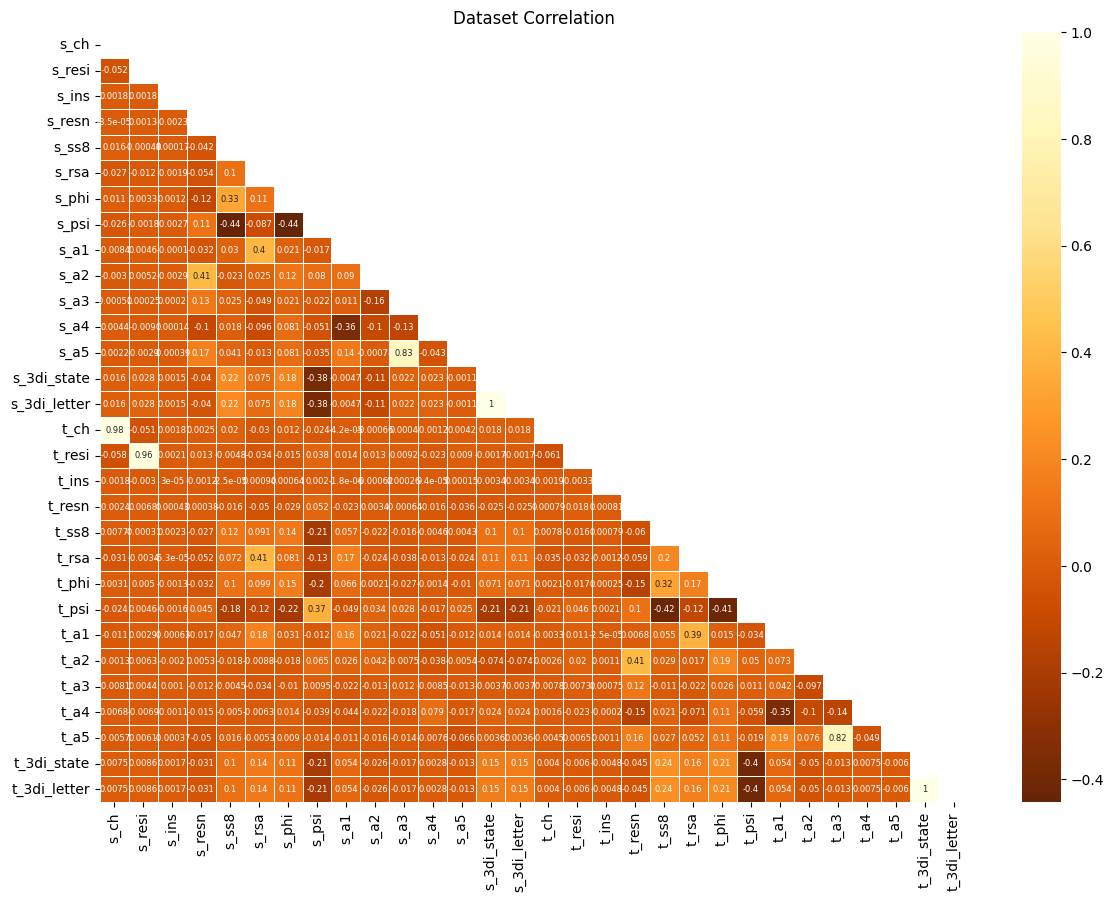

In [8]:
# Plot correlation heatmap
columns = list(df.columns)
plot_correlation_heatmap(df[columns], 'Dataset Correlation')

In [31]:
# Remove highly correleted variables
features = df.drop(columns=["pdb_id", "Interaction"])
new_features = features.drop(columns=[ 't_resi','t_psi','s_psi', 's_resi','s_a5','t_a5','t_ch','s_resi','t_ 3di_letter','s_ 3di_letter'])


In [32]:
# Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(new_features, target_encoded, test_size=0.3, random_state=42)

In [ ]:
print(target_encoded[0])

[1 1 0 0 0 0 0]


# Neural Network with oversampling
se con l'oversampling si va sopra il 5% le classi maggioritarie perdono di accuracy, ma quelle minoritarie migliorano f1.


In [35]:
# Oversampling on the last 5 classes: IONIC, PICATION, PIHBOND, PIPISTACK, SSBOND → columns 2 to 6
target_indices = list(range(2, 7))

X_augmented = []
Y_augmented = []

for i in target_indices:
    smote = SMOTE(sampling_strategy=0.075, random_state=44)  # 1-5% della classe maggioritaria
    try:
        X_res_i, y_res_i = smote.fit_resample(X_train, Y_train[:, i])
        n_new = X_res_i.shape[0] - X_train.shape[0]
        if n_new > 0:
            X_new = X_res_i[-n_new:]
            Y_new = np.zeros((n_new, Y_train.shape[1]))
            Y_new[:, i] = 1
            X_augmented.append(X_new)
            Y_augmented.append(Y_new)
    except ValueError:
        print(f"SMOTE skipped for label {i} (not enough samples)")

# Add oversamples to the train set
X_train_resampled = np.vstack([X_train] + X_augmented)
Y_train_resampled = np.vstack([Y_train] + Y_augmented)

In [22]:
# Count occurrences on Y_train_resampled
label_counts = np.sum(Y_train_resampled, axis=0)

labels = ['HBOND', 'VDW', 'IONIC', 'PICATION', 'PIHBOND', 'PIPISTACK', 'SSBOND']

# Print with labels
for label, count in zip(labels, label_counts):
    print(f"{label}: {int(count)} occurrences")

HBOND: 719409 occurrences
VDW: 501857 occurrences
IONIC: 72389 occurrences
PICATION: 73742 occurrences
PIHBOND: 74104 occurrences
PIPISTACK: 72232 occurrences
SSBOND: 74088 occurrences


In [10]:
def evaluate_model(y_pred_prob, Y_test):
    threshold = 0.5
    y_pred_bin = (y_pred_prob > threshold).astype(int)

    labels = ['HBOND', 'VDW', 'IONIC', 'PICATION', 'PIHBOND', 'PIPISTACK', 'SSBOND']

    report = classification_report(
        Y_test,
        y_pred_bin,
        target_names=labels,
        zero_division=0
    )

    print("Multi-Label Classification Report:\n")
    print(report)

    print("Per-class accuracy: \n")
    for i, label in enumerate(labels):
        acc = accuracy_score(Y_test[:, i], y_pred_bin[:, i])
        print(f"{label}: {acc:.4f}")

In [11]:
# Neural Network model definition
def build_report_model(input_dim):#, dropout1=0.5, dropout2=0.4):
    """
    Recreates the neural network from REPORT_nn.ipynb:
    - Two hidden Dense layers with relu
    - Single sigmoid output for binary classification
    """
    model = Sequential([
        Dense(64, kernel_initializer='he_uniform',activation='relu'),
        #LeakyReLU(alpha=0.1),#Dense(64, activation='elu'),#Dense(64, activation='relu', input_shape=(input_dim,)), #Dense(128, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(1e-4)),

        #Dropout(dropout1),
        Dense(32, activation='relu'),#, kernel_regularizer=l2(1e-4), activation='elu'
        #LeakyReLU(alpha=0.1),
        #Dropout(dropout2),
        Dense(7, activation='sigmoid')#, kernel_regularizer=l2(1e-4)
    ])
    return model

In [12]:
# Define the model
input_dim = X_train_resampled.shape[1]
model = build_report_model(input_dim)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(),
    metrics=['accuracy',AUC(curve='PR', name='aupr')]
)
early_stop = EarlyStopping(
    monitor='val_aupr',    #'val_aupr' , o 'accuracy'
    patience=3,                # ferma dopo 3 epoche senza miglioramento
    mode='max',                # vogliamo massimizzare l'AUPR o accuracy
    restore_best_weights=True # ripristina i pesi migliori alla fine
)

# Train
history = model.fit(
    X_train_resampled, Y_train_resampled,
    validation_data=(X_test, Y_test),
    epochs=20,#5
    callbacks=[early_stop],
    batch_size=1100,
    verbose=1
)

Epoch 1/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5925 - aupr: 0.6276 - loss: 0.2906 - val_accuracy: 0.6609 - val_aupr: 0.7092 - val_loss: 0.2141
Epoch 2/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6937 - aupr: 0.7591 - loss: 0.2035 - val_accuracy: 0.6713 - val_aupr: 0.7226 - val_loss: 0.2077
Epoch 3/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7031 - aupr: 0.7718 - loss: 0.1966 - val_accuracy: 0.6611 - val_aupr: 0.7195 - val_loss: 0.2083
Epoch 4/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7081 - aupr: 0.7783 - loss: 0.1934 - val_accuracy: 0.6528 - val_aupr: 0.7184 - val_loss: 0.2080
Epoch 5/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7110 - aupr: 0.7825 - loss: 0.1916 - val_accuracy: 0.6621 - val_aupr: 0.7239 - val_loss: 0.2071
Epoch 6/20
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7138 - aupr: 0.7860 - loss: 0.1899 - val_accuracy: 0.6669 - val_aupr: 0.7272 - val_loss: 0.2063
Epoch 7/20
118

In [13]:
# Evaluate Neural Network
y_prob_nn = model.predict(X_test)
evaluate_model(y_prob_nn, Y_test)

13249/13249 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
Multi-Label Classification Report:

              precision    recall  f1-score   support

       HBOND       0.76      0.90      0.82    308116
         VDW       0.53      0.60      0.57    215085
       IONIC       0.44      0.74      0.55     10245
    PICATION       0.24      0.83      0.37      2551
     PIHBOND       0.04      0.28      0.07       527
   PIPISTACK       0.74      0.98      0.84     11196
      SSBOND       0.70      1.00      0.82       612

   micro avg       0.66      0.78      0.71    548332
   macro avg       0.49      0.76      0.58    548332
weighted avg       0.66      0.78      0.72    548332
 samples avg       0.65      0.80      0.69    548332

Per-class accuracy: 

HBOND: 0.7202
VDW: 0.5325
IONIC: 0.9706
PICATION: 0.9832
PIHBOND: 0.9913
PIPISTACK: 0.9902
SSBOND: 0.9994


# Random Forest with oversampling

In [36]:
# Define Random Forest model
forest_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=15,
                                                            max_depth=25,
                                                            random_state=42))
# Train
forest_model.fit(X_train_resampled, Y_train_resampled)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=25,
                                                       n_estimators=15,
                                                       random_state=42))

In [37]:
# Evaluate Random Forest
y_pred_forest = forest_model.predict(X_test)

# Get soft predictions (probabilities)
y_prob_forest = forest_model.predict_proba(X_test)
y_prob_forest = np.column_stack([prob[:, 1] for prob in y_prob_forest])
evaluate_model(y_pred_forest, Y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: U

Multi-Label Classification Report:

              precision    recall  f1-score   support

       HBOND       0.80      0.92      0.86    308116
         VDW       0.63      0.54      0.59    215085
       IONIC       0.54      0.65      0.59     10245
    PICATION       0.40      0.56      0.47      2551
     PIHBOND       0.41      0.16      0.23       527
   PIPISTACK       0.77      0.98      0.86     11196
      SSBOND       0.80      0.97      0.88       612

   micro avg       0.74      0.77      0.75    548332
   macro avg       0.62      0.68      0.64    548332
weighted avg       0.73      0.77      0.74    548332
 samples avg       0.75      0.80      0.74    548332

Per-class accuracy: 

HBOND: 0.7792
VDW: 0.6092
IONIC: 0.9782
PICATION: 0.9923
PIHBOND: 0.9987
PIPISTACK: 0.9918
SSBOND: 0.9996


# Ensamble (Neural Network & Random Forest)

In [29]:
# Combine Neural Network and Random Forest and evaluate
weight_nn = 0.5
weight_forest = 0.5

ensamble_prob = (weight_nn * y_prob_nn + weight_forest * y_prob_forest)

evaluate_model(ensamble_prob, Y_test)

Multi-Label Classification Report:

              precision    recall  f1-score   support

       HBOND       0.79      0.93      0.85    308116
         VDW       0.63      0.53      0.58    215085
       IONIC       0.51      0.69      0.59     10245
    PICATION       0.35      0.67      0.46      2551
     PIHBOND       0.17      0.17      0.17       527
   PIPISTACK       0.75      0.98      0.85     11196
      SSBOND       0.71      1.00      0.83       612

   micro avg       0.73      0.77      0.75    548332
   macro avg       0.56      0.71      0.62    548332
weighted avg       0.72      0.77      0.74    548332
 samples avg       0.74      0.80      0.73    548332

Per-class accuracy: 

HBOND: 0.7653
VDW: 0.6043
IONIC: 0.9766
PICATION: 0.9907
PIHBOND: 0.9980
PIPISTACK: 0.9909
SSBOND: 0.9994


# Final model

oversampling per l'intero dataset

In [16]:
# Oversampling on the last 5 classes: IONIC, PICATION, PIHBOND, PIPISTACK, SSBOND → columns 2 to 6
target_indices = list(range(2, 7))

X_augmented = []
Y_augmented = []

for i in target_indices:
    smote = SMOTE(sampling_strategy=0.05, random_state=44)  # 1-5% della classe maggioritaria
    try:
        X_res_i, y_res_i = smote.fit_resample(new_features, target_encoded[:, i])
        n_new = X_res_i.shape[0] - new_features.shape[0]
        if n_new > 0:
            X_new = X_res_i[-n_new:]
            Y_new = np.zeros((n_new, target_encoded.shape[1]))
            Y_new[:, i] = 1
            X_augmented.append(X_new)
            Y_augmented.append(Y_new)
    except ValueError:
        print(f"SMOTE skipped for label {i} (not enough samples)")

# Add oversamples to the train set
X_train_resampled = np.vstack([new_features] + X_augmented)
Y_train_resampled = np.vstack([target_encoded] + Y_augmented)

retrain sull intero dataset

In [17]:
# Define Random Forest model
forest_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=15,
                                                            max_depth=25,
                                                            random_state=42))
# Train
forest_model.fit(X_train_resampled, Y_train_resampled)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=25,
                                                       n_estimators=15,
                                                       random_state=42))

salvare il modello

In [18]:
import joblib
joblib.dump(forest_model, "random_forest_model.joblib", compress=('xz', 9))#'gzip',3
# -> crea il file "random_forest_model.joblib" sul disco

# Per ricaricarlo in un secondo momento:
#rf_loaded = joblib.load("random_forest_model.joblib")

['random_forest_model.joblib']